# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix

In [2]:
pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 88.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import mlflow
import mlflow.sklearn
import dagshub

dagshub.init(repo_owner='adzid23', repo_name='Freeuni_ML_Fraud_Detection', mlflow=True)
mlflow.set_experiment("RandomForest_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=6c650727-48f6-44b4-b78c-327dbd0fcd8e&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a8328b92d60f62d7106783aefb65ce4d5970488786727b6e158e0414c677f907




Accessing as adzid23

Initialized MLflow to track repo "adzid23/Freeuni_ML_Fraud_Detection"

Repository adzid23/Freeuni_ML_Fraud_Detection initialized!

2026/05/03 21:15:36 INFO mlflow.tracking.fluent: Experiment with name 'RandomForest_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/d5a946b142574e56a31489836d5a9e93', creation_time=1777842936669, experiment_id='3', last_update_time=1777842936669, lifecycle_stage='active', name='RandomForest_Training', tags={}, trace_location=None, workspace='default'>

# Cleaning

In [4]:
DATA_PATH = '/kaggle/input/competitions/ieee-fraud-detection'

train_transaction = pd.read_csv(f'{DATA_PATH}/train_transaction.csv')
train_identity    = pd.read_csv(f'{DATA_PATH}/train_identity.csv')

df = train_transaction.merge(train_identity, on='TransactionID', how='left')

y = df['isFraud']
X = df.drop(columns=['isFraud', 'TransactionID'])

null_frac    = X.isnull().mean()
cols_to_drop = null_frac[null_frac > 0.5].index.tolist()
X = X.drop(columns=cols_to_drop)
X = X.drop(columns=['TransactionDT'], errors='ignore')

print(f"Shape after merge: {df.shape}")
print(f"Dropped {len(cols_to_drop)} high-null columns")
print(f"Shape after cleaning: {X.shape}")

with mlflow.start_run(run_name="RF_Cleaning"):
    mlflow.log_params({
        "null_threshold": 0.5,
        "dropped_cols": len(cols_to_drop),
    })
    mlflow.log_metric("cols_after_cleaning", X.shape[1])

Shape after merge: (590540, 434)
Dropped 214 high-null columns
Shape after cleaning: (590540, 217)
🏃 View run RF_Cleaning at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3/runs/d1cd843fafea4e15841481b5204e92dd
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3


# Feature Engineering

In [5]:
with mlflow.start_run(run_name="RF_Feature_Engineering"):

    X['hour'] = (df['TransactionDT'] // 3600) % 24
    X['day']  = (df['TransactionDT'] // (3600 * 24)) % 7
    X['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

    cat_cols = X.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        freq_map = X[col].value_counts(normalize=True).to_dict()
        X[col] = X[col].map(freq_map).fillna(0)

    card1_stats = X.groupby('card1')['TransactionAmt'].agg(['mean', 'std']).reset_index()
    card1_stats.columns = ['card1', 'card1_amt_mean', 'card1_amt_std']
    X = X.merge(card1_stats, on='card1', how='left')

    card2_stats = X.groupby('card2')['TransactionAmt'].agg(['mean', 'std']).reset_index()
    card2_stats.columns = ['card2', 'card2_amt_mean', 'card2_amt_std']
    X = X.merge(card2_stats, on='card2', how='left')

    X['card1_amt_diff'] = X['TransactionAmt'] - X['card1_amt_mean']

    print(f"Encoded {len(cat_cols)} categorical columns")
    print(f"Shape after feature engineering: {X.shape}")

    mlflow.log_params({
        "time_features": "hour, day",
        "log_transform": "TransactionAmt",
        "cat_encoding": "frequency",
        "aggregation_features": "card1_amt_mean, card1_amt_std, card2_amt_mean, card2_amt_std, card1_amt_diff"
    })
    mlflow.log_metric("total_features", X.shape[1])

Encoded 9 categorical columns
Shape after feature engineering: (590540, 225)
🏃 View run RF_Feature_Engineering at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3/runs/7cea39fd01504c0f9994cdd5ad4f4961
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3


# Feature Selection

In [6]:
with mlflow.start_run(run_name="RF_Feature_Selection"):

    num_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
    low_var_cols = [c for c in num_cols if X[c].std() < 0.01]
    X = X.drop(columns=low_var_cols)
    print(f"Dropped {len(low_var_cols)} near-constant columns")

    corr_matrix    = X.corr().abs()
    upper          = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.9)]
    X = X.drop(columns=high_corr_cols)
    print(f"Dropped {len(high_corr_cols)} highly correlated columns")
    print(f"Final feature count: {X.shape[1]}")

    mlflow.log_params({
        "variance_threshold": 0.01,
        "correlation_threshold": 0.9,
    })
    mlflow.log_metric("dropped_low_var", len(low_var_cols))
    mlflow.log_metric("dropped_high_corr", len(high_corr_cols))
    mlflow.log_metric("features_selected", X.shape[1])

Dropped 2 near-constant columns
Dropped 104 highly correlated columns
Final feature count: 119
🏃 View run RF_Feature_Selection at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3/runs/4a8537d7c8294692b037c288e7660eb8
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3


## RF Feature Importance

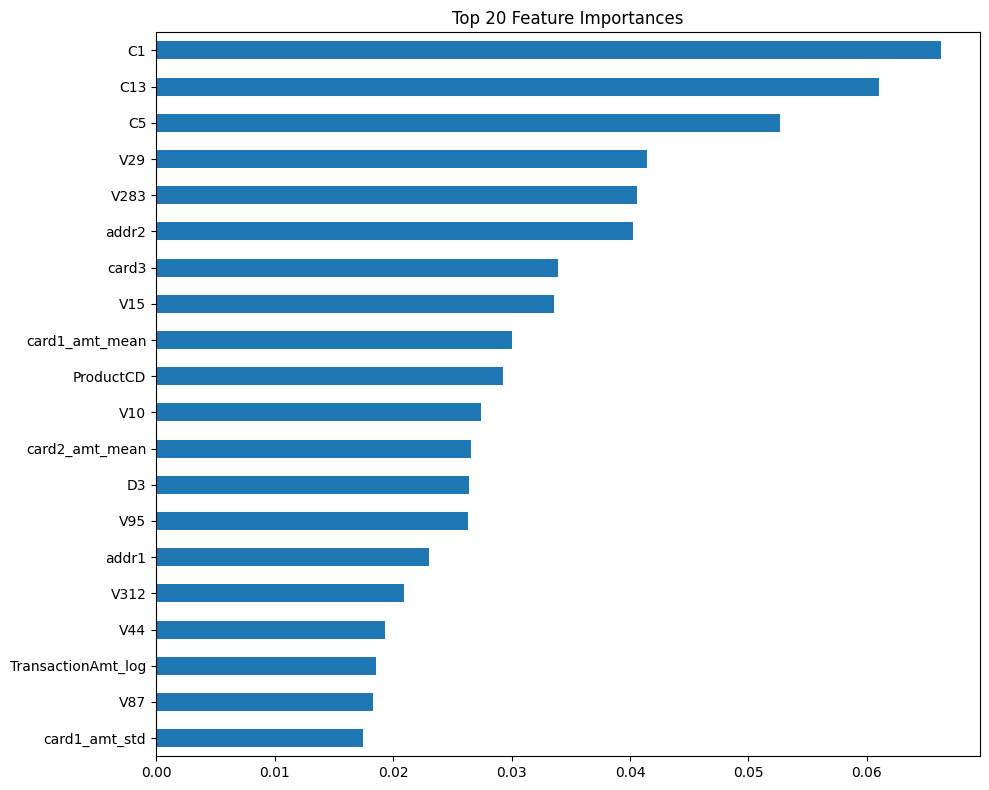

Selected top 80 features
🏃 View run RF_Feature_Importance_Selection at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3/runs/5af81b48cd8c42f087320b8ae90f94c0
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

with mlflow.start_run(run_name="RF_Feature_Importance_Selection"):

    selector = RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    )
    selector.fit(X_train.fillna(-999), y_train)

    importances = pd.Series(selector.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False)

    top_features = importances.head(80).index.tolist()
    X_train = X_train[top_features]
    X_test  = X_test[top_features]

    fig, ax = plt.subplots(figsize=(10, 8))
    importances.head(20).plot(kind='barh', ax=ax)
    ax.set_title("Top 20 Feature Importances")
    ax.invert_yaxis()
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance_top20.png")
    plt.show()

    print(f"Selected top {len(top_features)} features")

    mlflow.log_params({
        "selection_method": "RF feature importance",
        "n_estimators_selector": 50,
        "top_n_features": 80,
    })
    mlflow.log_metric("features_after_importance_selection", len(top_features))

# Training

## Run 1 - n_estimators sweep

In [8]:
with mlflow.start_run(run_name="RF_Estimators_Sweep"):

    for n_est in [50, 100, 200, 300]:

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model',   RandomForestClassifier(
                n_estimators=n_est,
                max_depth=10,
                class_weight='balanced',
                n_jobs=-1,
                random_state=42,
                oob_score=True   
            ))
        ])

        pipe.fit(X_train, y_train)

        train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
        test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])
        oob_score = pipe.named_steps['model'].oob_score_

        mlflow.log_metric("train_auc", train_auc, step=n_est)
        mlflow.log_metric("test_auc",  test_auc,  step=n_est)
        mlflow.log_metric("oob_score", oob_score, step=n_est)

        print(f"n_estimators={n_est:>4} | train={train_auc:.4f} | test={test_auc:.4f} | oob={oob_score:.4f}")

n_estimators=  50 | train=0.9105 | test=0.8942 | oob=0.8613
n_estimators= 100 | train=0.9126 | test=0.8963 | oob=0.8647
n_estimators= 200 | train=0.9128 | test=0.8963 | oob=0.8649
n_estimators= 300 | train=0.9127 | test=0.8962 | oob=0.8649
🏃 View run RF_Estimators_Sweep at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3/runs/183860d2398449fc9a494aacbcf55b54
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3


## Run 2 - max_depth sweep

In [9]:
with mlflow.start_run(run_name="RF_Depth_Sweep"):

    for depth in [5, 8, 10, 15, None]:

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model',   RandomForestClassifier(
                n_estimators=100,
                max_depth=depth,
                class_weight='balanced',
                n_jobs=-1,
                random_state=42,
                oob_score=True
            ))
        ])

        pipe.fit(X_train, y_train)

        train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
        test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])
        gap       = train_auc - test_auc

        depth_label = str(depth) if depth is not None else "None"
        mlflow.log_metric("train_auc", train_auc, step=depth if depth else 30)
        mlflow.log_metric("test_auc",  test_auc,  step=depth if depth else 30)

        print(f"max_depth={depth_label:>5} | train={train_auc:.4f} | test={test_auc:.4f} | gap={gap:.4f}")

max_depth=    5 | train=0.8509 | test=0.8474 | gap=0.0035
max_depth=    8 | train=0.8872 | test=0.8778 | gap=0.0094
max_depth=   10 | train=0.9126 | test=0.8963 | gap=0.0163
max_depth=   15 | train=0.9666 | test=0.9262 | gap=0.0404
max_depth= None | train=1.0000 | test=0.9370 | gap=0.0629
🏃 View run RF_Depth_Sweep at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3/runs/d9244d1dc1954733a6b2412ed2b3c846
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3


## Run 3 - Final Model

In [10]:
with mlflow.start_run(run_name="RF_FinalModel"):

    final_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42,
            oob_score=True
        ))
    ])

    final_pipeline.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, final_pipeline.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  final_pipeline.predict_proba(X_test)[:, 1])
    oob_score = final_pipeline.named_steps['model'].oob_score_

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")
    print(f"OOB Score: {oob_score:.4f}")
    print(f"Gap:       {(train_auc - test_auc):.4f}")

    mlflow.log_params({
        "n_estimators": 100,
        "max_depth": "None",
        "class_weight": "balanced",
        "oob_score": True,
        "reason": "best test AUC from depth sweep"
    })
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("test_auc",  test_auc)
    mlflow.log_metric("oob_score", oob_score)
    mlflow.log_metric("overfit_gap", train_auc - test_auc)

    mlflow.sklearn.log_model(
        final_pipeline,
        artifact_path="rf_fraud_pipeline",
        registered_model_name="RF_Fraud_Pipeline"
    )
    print("Model saved to Model Registry as RF_Fraud_Pipeline")

Train AUC: 1.0000
Test  AUC: 0.9370
OOB Score: 0.9796
Gap:       0.0629


2026/05/03 21:39:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 21:40:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RF_Fraud_Pipeline'.
2026/05/03 21:40:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RF_Fraud_Pipeline, version 1
Created version '1' of model 'RF_Fraud_Pipeline'.


Model saved to Model Registry as RF_Fraud_Pipeline
🏃 View run RF_FinalModel at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3/runs/21ae367ae54c4519819aef765bd176f2
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/3
